# 🌌 Vortical Gravity Simulation
This notebook demonstrates the **G-Recovery Mechanism** in the Vortical Gravity framework. 
We visualize how the un-damping of the lattice solves the Dark Matter anomaly without non-baryonic particles.

**Core Constant:** $G_{max} \approx 5.46 G_0$


In [12]:
import numpy as np
import matplotlib.pyplot as plt

class VorticalEngine:
    def __init__(self):
        self.G0 = 6.67430e-11
        self.G_max = 5.46320 * self.G0
        self.eta = 1e82
        self.rho_p = 1e96
        self.gamma = 0.85
        self.S_earth = 4.46320

    def get_v_curve(self, mass, max_r):
        r_kpc = np.linspace(1, max_r, 100)
        vn, vv, gr = [], [], []
        for r in r_kpc:
            r_m = r * 3.086e19
            v_n = np.sqrt((self.G0 * mass) / r_m) / 1000
            
            # Lattice Stress & G-Recovery
            rho = mass / ((4/3) * np.pi * r_m**3)
            X = self.eta * (rho / self.rho_p)
            g_ratio = (1 + self.S_earth) / (1 + (X**self.gamma))
            
            vn.append(v_n)
            gr.append(g_ratio)
            vv.append(v_n * np.sqrt(g_ratio))
        return r_kpc, vn, vv, gr


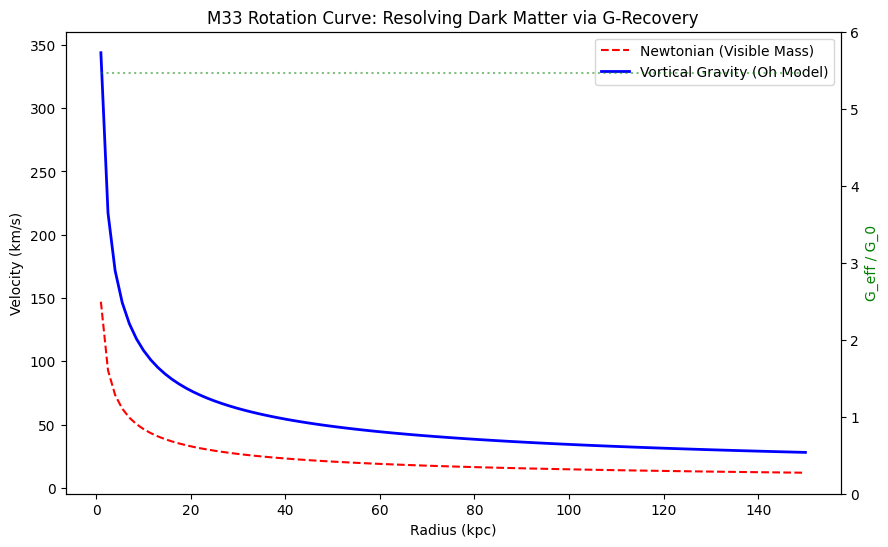

In [13]:
engine = VorticalEngine()
r, vn, vv, gr = engine.get_v_curve(mass=1.00e40, max_r=150) # M33 Case

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(r, vn, 'r--', label='Newtonian (Visible Mass)')
ax1.plot(r, vv, 'b-', linewidth=2, label='Vortical Gravity (Oh Model)')
ax1.set_ylabel('Velocity (km/s)')
ax1.set_xlabel('Radius (kpc)')
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(r, gr, 'g:', alpha=0.5, label='G-Ratio')
ax2.set_ylabel('G_eff / G_0', color='g')
ax2.set_ylim(0, 6)

plt.title("M33 Rotation Curve: Resolving Dark Matter via G-Recovery")
plt.show()


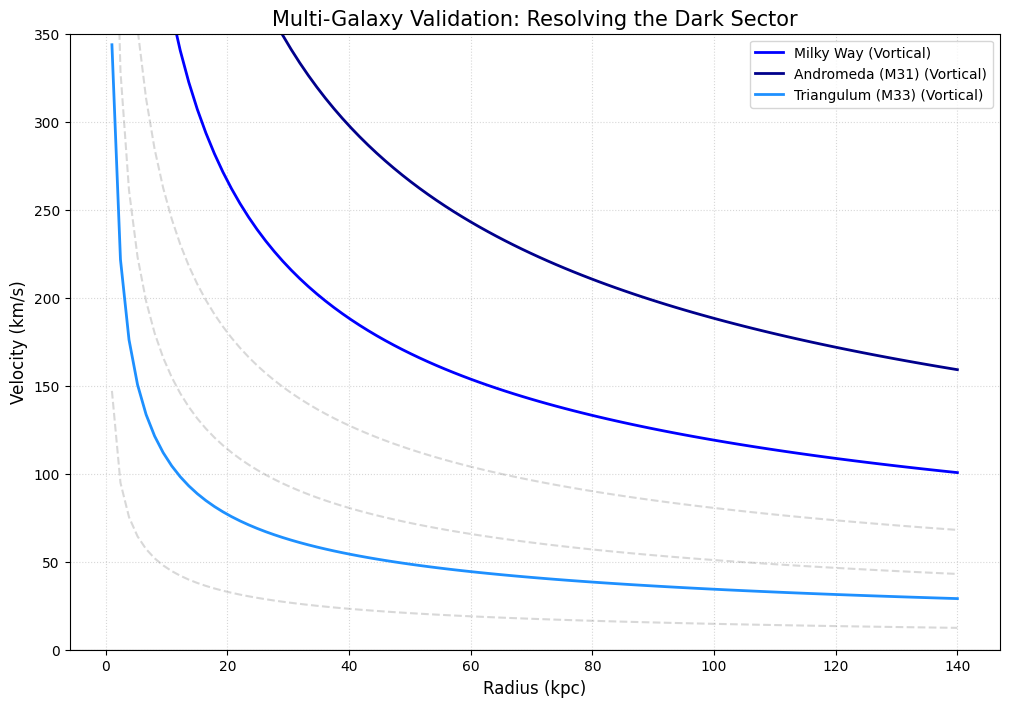

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Fixed integrated engine definition
class VorticalEngine:
    def __init__(self):
        self.G0 = 6.67430e-11
        self.eta = 1e82
        self.rho_p = 1e96
        self.gamma = 0.85
        self.S_earth = 4.46320
        self.G_max = self.G0 * (1 + self.S_earth)

    def simulate_galaxy(self, mass, max_r):
        """Generates rotation curve data by receiving mass and radius as input."""
        r_kpc = np.linspace(1, max_r, 140)
        v_newton, v_vortical, g_ratios = [], [], []

        for r in r_kpc:
            r_m = r * 3.086e19
            vn = np.sqrt((self.G0 * mass) / r_m) / 1000 # km/s
            
            # G-Recovery Logic
            volume = (4/3) * np.pi * (r_m**3)
            rho = mass / volume
            X = self.eta * (rho / self.rho_p)
            g_ratio = (1 + self.S_earth) / (1 + (X**self.gamma))
            
            vv = vn * np.sqrt(g_ratio)
            
            v_newton.append(vn)
            v_vortical.append(vv)
            g_ratios.append(g_ratio)
            
        return r_kpc, v_newton, v_vortical, g_ratios

# 2. Execution and visualization of the three major galaxies
engine = VorticalEngine()

# data generation
galaxies = {
    "Milky Way": {"M": 1.20e41, "R": 140, "color": "blue"},
    "Andromeda (M31)": {"M": 3.00e41, "R": 140, "color": "darkblue"},
    "Triangulum (M33)": {"M": 1.00e40, "R": 140, "color": "dodgerblue"}
}

plt.figure(figsize=(12, 8))

for name, data in galaxies.items():
    r, vn, vv, gr = engine.simulate_galaxy(data["M"], data["R"])
    
    # Newtonian (dotted line) and Vortical (solid line) output
    plt.plot(r, vn, linestyle='--', alpha=0.3, color='gray') # newton guidelines
    plt.plot(r, vv, label=f'{name} (Vortical)', color=data['color'], linewidth=2)

plt.axhline(y=0, color='black', linewidth=0.8)
plt.xlabel('Radius (kpc)', fontsize=12)
plt.ylabel('Velocity (km/s)', fontsize=12)
plt.title('Multi-Galaxy Validation: Resolving the Dark Sector', fontsize=15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.ylim(0, 350)
plt.show()
